# Report figures export


Using results: C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\tables\experiment_results_full_online_none.parquet
Using rounds: C:\Users\hovha\Downloads\bt4014_job_ui_bandit\data\processed\rounds_all_meta.parquet


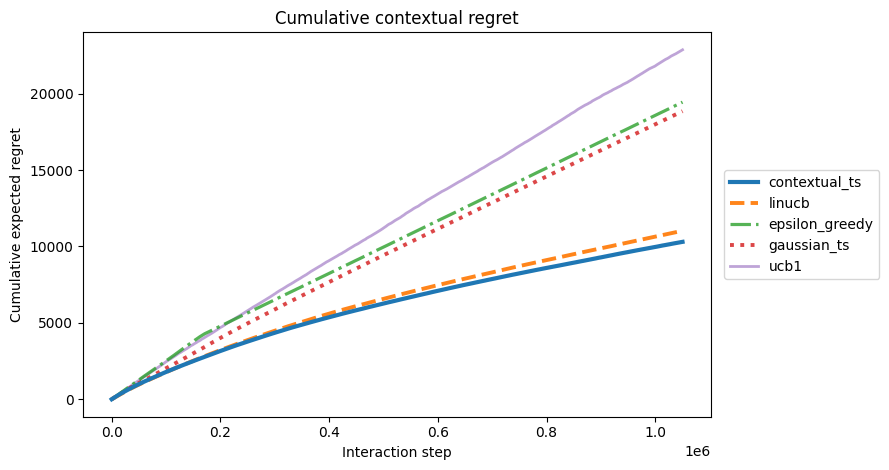

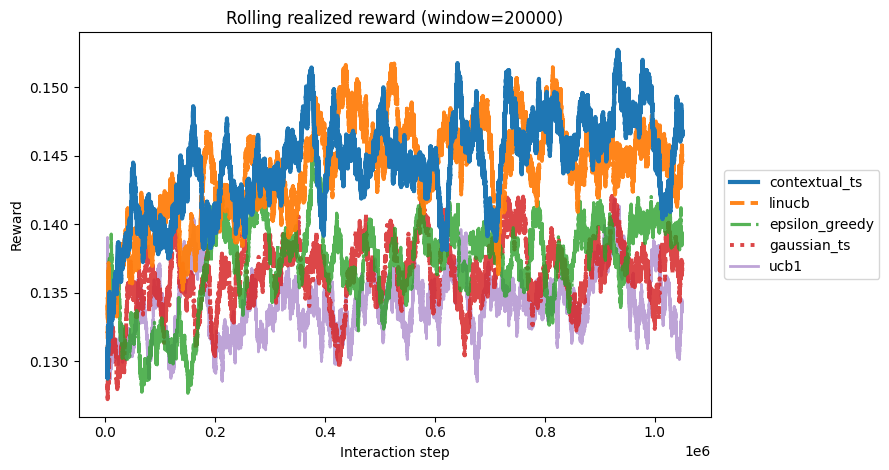

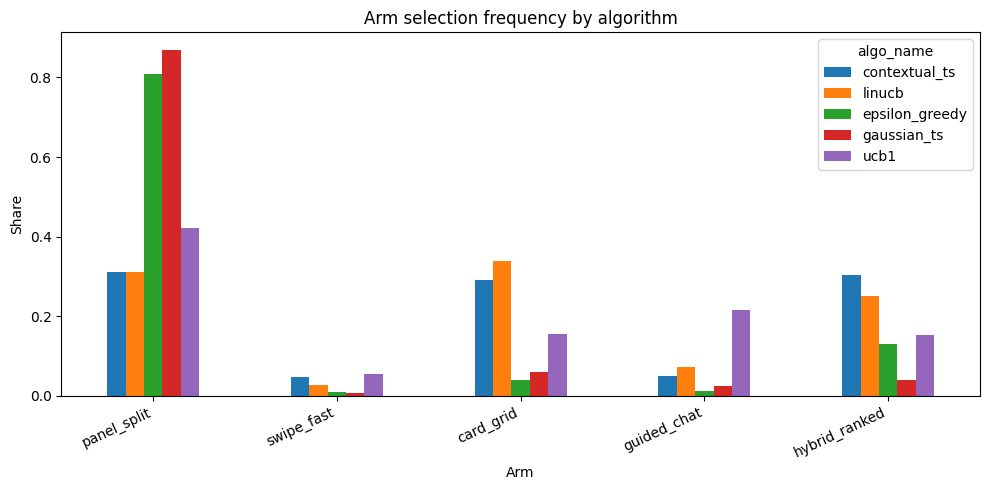

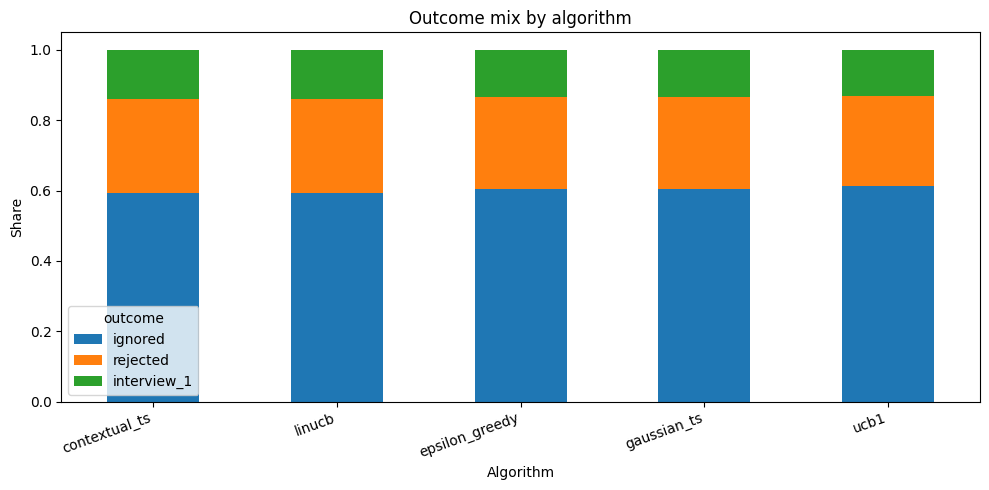

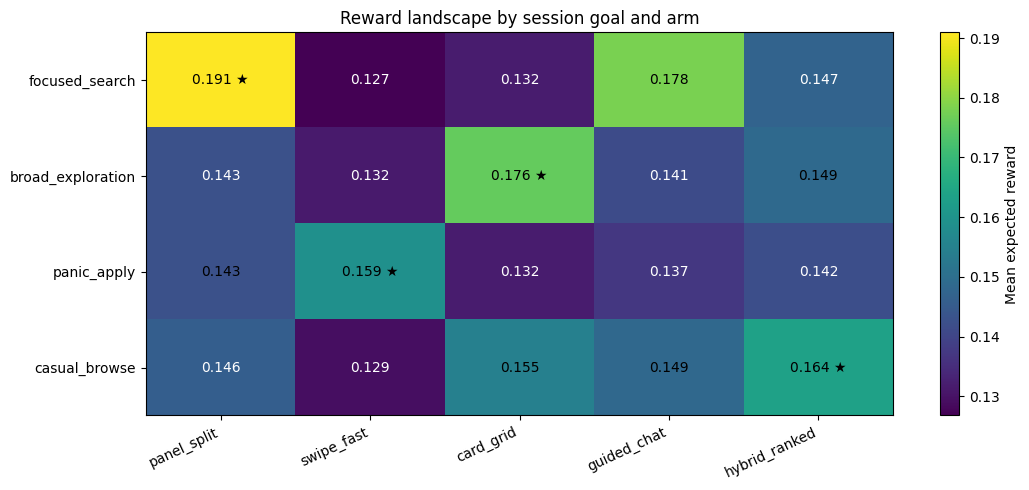

Saved:
 - C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\figures\cumulative_contextual_regret.png
 - C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\figures\rolling_avg_reward.png
 - C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\figures\arm_selection_frequency.png
 - C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\figures\outcome_mix_by_algorithm.png
 - C:\Users\hovha\Downloads\bt4014_job_ui_bandit\outputs\figures\reward_landscape_heatmap.png


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == "notebooks" else cwd

fig_dir = root / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

result_candidates = [
    root / "outputs" / "tables" / "experiment_results_full_online_none.parquet",
    root / "outputs" / "tables" / "experiment_results_medium_online_none.parquet",
    root / "outputs" / "tables" / "experiment_results_debug_online_none.parquet",
]

res_path = next((p for p in result_candidates if p.exists()), None)
if res_path is None:
    raise FileNotFoundError("No experiment_results parquet found in outputs/tables")

rounds_path = root / "data" / "processed" / "rounds_all_meta.parquet"
if not rounds_path.exists():
    raise FileNotFoundError("Missing data/processed/rounds_all_meta.parquet")

print("Using results:", res_path)
print("Using rounds:", rounds_path)

res = pd.read_parquet(res_path).copy()
rounds = pd.read_parquet(rounds_path).copy()

res["step_index"] = res.groupby(["seed", "algo_name"]).cumcount()

avg = (
    res.groupby(["algo_name", "step_index"], as_index=False)
       .agg(
           cumulative_reward=("cumulative_reward", "mean"),
           cumulative_expected_regret=("cumulative_expected_regret", "mean"),
           reward_realized=("reward_realized", "mean"),
       )
)

algo_order = ["contextual_ts", "linucb", "epsilon_greedy", "gaussian_ts", "ucb1"]
algo_order = [a for a in algo_order if a in res["algo_name"].unique()]

arm_order = ["panel_split", "swipe_fast", "card_grid", "guided_chat", "hybrid_ranked"]

styles = {
    "contextual_ts": dict(linestyle="-",  linewidth=3.0, alpha=1.00, zorder=5),
    "linucb":        dict(linestyle="--", linewidth=2.8, alpha=0.95, zorder=4),
    "epsilon_greedy":dict(linestyle="-.", linewidth=2.3, alpha=0.80, zorder=3),
    "gaussian_ts":   dict(linestyle=":",  linewidth=2.8, alpha=0.85, zorder=2),
    "ucb1":          dict(linestyle="-",  linewidth=2.0, alpha=0.60, zorder=1),
}

if "debug" in res_path.name:
    window = 200
elif "medium" in res_path.name:
    window = 1000
else:
    window = 20000

# 1) cumulative contextual regret
fig, ax = plt.subplots(figsize=(9, 4.8))
for name in algo_order:
    g = avg[avg["algo_name"] == name].sort_values("step_index")
    ax.plot(
        g["step_index"],
        g["cumulative_expected_regret"],
        label=name,
        **styles.get(name, {})
    )

ax.set_title("Cumulative contextual regret")
ax.set_xlabel("Interaction step")
ax.set_ylabel("Cumulative expected regret")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "cumulative_contextual_regret.png", dpi=220, bbox_inches="tight")
plt.show()


# 2) rolling average realized reward
fig, ax = plt.subplots(figsize=(9, 4.8))
for name in algo_order:
    g = avg[avg["algo_name"] == name].sort_values("step_index").copy()
    g["rolling_reward"] = g["reward_realized"].rolling(
        window, min_periods=max(10, window // 5)
    ).mean()
    ax.plot(
        g["step_index"],
        g["rolling_reward"],
        label=name,
        **styles.get(name, {})
    )

ax.set_title(f"Rolling realized reward (window={window})")
ax.set_xlabel("Interaction step")
ax.set_ylabel("Reward")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
fig.tight_layout()
fig.savefig(fig_dir / "rolling_avg_reward.png", dpi=220, bbox_inches="tight")
plt.show()


# 3) arm selection frequency
freq = (
    res.groupby(["algo_name", "arm_selected_name"])
       .size()
       .rename("count")
       .reset_index()
)
freq["share"] = freq.groupby("algo_name")["count"].transform(lambda x: x / x.sum())

pivot = (
    freq.pivot(index="arm_selected_name", columns="algo_name", values="share")
        .fillna(0.0)
        .reindex(arm_order)
)
pivot = pivot[[c for c in algo_order if c in pivot.columns]]

ax = pivot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Arm selection frequency by algorithm")
ax.set_xlabel("Arm")
ax.set_ylabel("Share")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "arm_selection_frequency.png", dpi=220, bbox_inches="tight")
plt.show()


# 4) outcome mix by algorithm
mix = (
    res.groupby(["algo_name", "outcome"])
       .size()
       .rename("count")
       .reset_index()
)
mix["share"] = mix.groupby("algo_name")["count"].transform(lambda x: x / x.sum())

mix_pivot = mix.pivot(index="algo_name", columns="outcome", values="share").fillna(0.0)
for col in ["ignored", "rejected", "interview_1"]:
    if col not in mix_pivot.columns:
        mix_pivot[col] = 0.0
mix_pivot = mix_pivot[["ignored", "rejected", "interview_1"]]
mix_pivot = mix_pivot.reindex(algo_order)

ax = mix_pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
ax.set_title("Outcome mix by algorithm")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Share")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(fig_dir / "outcome_mix_by_algorithm.png", dpi=220, bbox_inches="tight")
plt.show()


# 5) reward landscape heatmap
reward_cols = {a: f"exp_reward_{a}" for a in arm_order}
landscape = rounds.groupby("session_goal")[[reward_cols[a] for a in arm_order]].mean()
landscape = landscape.rename(columns={v: k for k, v in reward_cols.items()})
landscape = landscape.reindex(columns=arm_order)

session_order = ["focused_search", "broad_exploration", "panic_apply", "casual_browse"]
session_order = [s for s in session_order if s in landscape.index] + [
    s for s in landscape.index if s not in session_order
]
landscape = landscape.reindex(session_order)

fig, ax = plt.subplots(figsize=(11, 5))
img = ax.imshow(landscape.values, aspect="auto")

for i in range(landscape.shape[0]):
    row = landscape.iloc[i].values
    best = int(row.argmax())
    row_mean = row.mean()
    for j, val in enumerate(row):
        txt = f"{val:.3f}" + (" ★" if j == best else "")
        color = "white" if val < row_mean else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=10, color=color)

ax.set_xticks(range(len(landscape.columns)))
ax.set_xticklabels(landscape.columns, rotation=25, ha="right")
ax.set_yticks(range(len(landscape.index)))
ax.set_yticklabels(landscape.index)
ax.set_title("Reward landscape by session goal and arm")
fig.colorbar(img, ax=ax, label="Mean expected reward")
fig.tight_layout()
fig.savefig(fig_dir / "reward_landscape_heatmap.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:")
for name in [
    "cumulative_contextual_regret.png",
    "rolling_avg_reward.png",
    "arm_selection_frequency.png",
    "outcome_mix_by_algorithm.png",
    "reward_landscape_heatmap.png",
]:
    print(" -", fig_dir / name)